# Representational similarity analysis among multiple neural manifolds


In addition to measuring the similairity between two neural manifolds, CaTrace also provides convenient APIs to compute the pairwise similarity between multiple neural manifolds.
We will download an example dataset from a zebrafish olfactory brain region and demonstrate how to compute the pairwise similarities.

In [17]:
# Download example dataset

# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
demo_data_dir = kagglehub.dataset_download("hubosynapse/catrace-demo")

print("Dataset downloaded to:", demo_data_dir)

Dataset downloaded to: /home/hubo/.cache/kagglehub/datasets/hubosynapse/catrace-demo/versions/1


In [18]:
import os
from catrace.dataio import load_tracedf_from_hdf5
dff = load_tracedf_from_hdf5(os.path.join(demo_data_dir, "example_manifolds_zebrafish_pDp.h5"))
dff

neuron_id             0         3         6         9         12        15    \
odor trial frame                                                               
Phe  0     0      0.087327  0.000000  0.364393  3.401696  0.198831  0.222916   
           1      0.124883  0.000000  0.389797  2.382160  0.183961  0.281749   
           2      0.193008  0.000000  0.261387  1.833974  0.188226  0.294678   
           3      0.156106  0.101239  0.328432  1.030327  0.311956  0.427573   
           4      0.178299  0.061524  0.251610  0.782781  0.300017  0.427398   
...                    ...       ...       ...       ...       ...       ...   
GCA  2     156    0.397823  0.032051  0.197996  1.149775  0.342550  0.133098   
           157    0.395247  0.000000  0.147733  1.927241  0.343461  0.104777   
           158    0.406598  0.033626  0.150963  1.658847  0.465890  0.037147   
           159    0.548564  0.117669  0.038714  1.228765  0.437184  0.000000   
           160    0.363364  0.114395  0.197050  0.698210  0.438365  0.037931   

neuron_id             18        21        24        27    ...      1320  \
odor trial frame                                          ...             
Phe  0     0      0.156371  0.111882  0.062771  0.211053  ...  0.000000   
           1      0.113549  0.177746  0.072316  0.187708  ...  0.000000   
           2      0.114015  0.401941  0.110502  0.210519  ...  0.000000   
           3      0.071192  0.480165  0.069942  0.143565  ...  0.000000   
           4      0.166722  0.302050  0.033885  0.152268  ...  0.000000   
...                    ...       ...       ...       ...  ...       ...   
GCA  2     156    0.073760  0.019886  0.453068  0.000000  ...  0.203370   
           157    0.073063  0.038100  0.600632  0.000000  ...  0.222437   
           158    0.080100  0.033084  0.484723  0.000000  ...  0.231907   
           159    0.115039  0.000000  0.397446  0.000000  ...  0.099963   
           160    0.217217  0.000000  0.260369  0.000000  ...  0.007203   

neuron_id             1323      1326      1329      1332      1335      1338  \
odor trial frame                                                               
Phe  0     0      0.000000  0.096166  0.081480  0.061187  0.162319  0.229935   
           1      0.024929  0.075745  0.039305  0.097043  0.123529  0.341941   
           2      0.026147  0.010184  0.081434  0.094906  0.146486  0.574860   
           3      0.046711  0.084686  0.046592  0.071153  0.066409  1.140675   
           4      0.053644  0.107827  0.052891  0.069509  0.082030  1.076845   
...                    ...       ...       ...       ...       ...       ...   
GCA  2     156    0.584936  0.216866  0.611091  0.166145  1.826299  0.297510   
           157    0.344783  0.150408  0.540862  0.216696  2.579315  0.296145   
           158    0.208518  0.251466  0.460306  0.217961  2.323958  0.262159   
           159    0.142863  0.178874  0.377149  0.158550  2.331792  0.339583   
           160    0.118876  0.212228  0.411285  0.183784  1.892450  0.458288   

neuron_id             1341      1344      1347  
odor trial frame                                
Phe  0     0      0.111886  0.186035  0.109348  
           1      0.114628  0.459607  0.123736  
           2      0.016349  0.357506  0.086978  
           3      0.043885  0.251076  0.040477  
           4      0.000000  0.180134  0.058504  
...                    ...       ...       ...  
GCA  2     156    0.090758  0.000000  1.886180  
           157    0.012790  0.000000  1.413937  
           158    0.025896  0.000000  1.200838  
           159    0.000000  0.000000  1.283291  
           160    0.033679  0.000000  1.174082  

[2898 rows x 450 columns]

In [19]:
from catrace.process_time_trace import select_odors_df

dff = select_odors_df(dff, odors=['Arg', 'Phe', 'TCA'])

frame


In [20]:
# Visualize the manifolds
import matplotlib.pyplot as plt
from catrace.dimensionality_reduction import compute_umap, plot_embed_2d

umap_params = {
    'n_components': 2,
    'n_neighbors': 15,
    'min_dist': 0.8,
    'metric': 'euclidean',
    'random_state': 42,
}
embeddf = compute_umap(dff, umap_params)


/home/hubo/Software/miniconda3/envs/catrace/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hubo/Software/miniconda3/envs/catrace/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/hubo/Projects/Ca_imaging/scripts/catrace/catrace/dimensionality_reduction.py:328: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = embeddf.groupby(level=manifold_level)


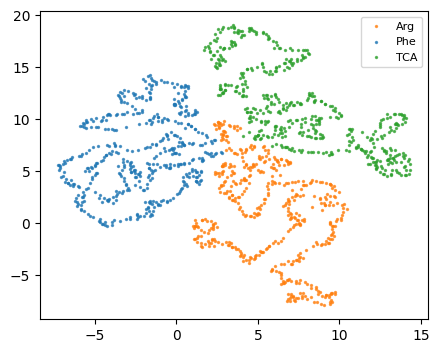

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
component_idx = [0, 1]
plot_embed_2d(embeddf, component_idx, ax=ax, manifold_level='odor')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)


In [22]:
# Compute pattern correlation, cosine distance, Euclidean distance and Mahalanobis distance